# Webinar 4 — ARIMA, SARIMA y ARIMAX
**Dataset:** Precio del Petróleo WTI (semanal)

---

In [63]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#F8FBFC',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11})
C = {'arima':'#1B8EA6','sarima':'#FFB703','arimax':'#E05C2A','real':'#0D1B2A'}

## 1. Datos

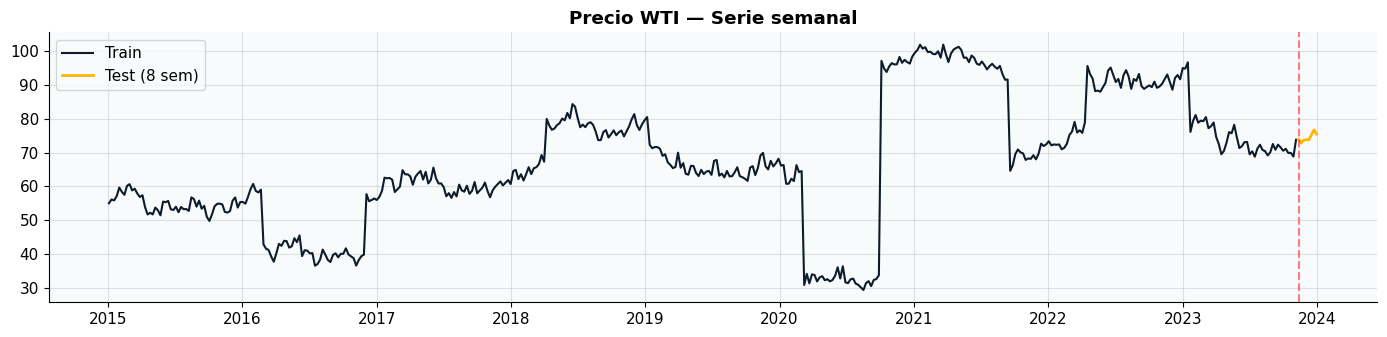

In [64]:
df = pd.read_csv('wti.csv', parse_dates=['date'], index_col='date')
serie = df['price'].asfreq('W')

HORIZON = 8  # semanas — horizonte corto donde ARIMA funciona bien

exog = pd.DataFrame({
    'covid': np.where(serie.index >= '2020-03-01', 1, 0),
    'gdp': np.log(1 + np.arange(len(serie)))  # tendencia
}, index=serie.index)

train_s = serie.iloc[:-HORIZON]
test_s  = serie.iloc[-HORIZON:]
exog_train = exog.iloc[:-HORIZON].dropna()
exog_test  = exog.iloc[-HORIZON:]

# Alinear train con exog (dropna elimina la primera fila)
train_s = train_s.loc[exog_train.index]

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(train_s.index, train_s, color=C['real'], lw=1.5, label='Train')
ax.plot(test_s.index,  test_s,  color=C['sarima'], lw=2,   label=f'Test ({HORIZON} sem)')
ax.axvline(test_s.index[0], color='red', linestyle='--', alpha=0.5)
ax.set_title('Precio WTI — Serie semanal', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Diagnósticos

0.0891916584748556 0.0 0.02979963243674899


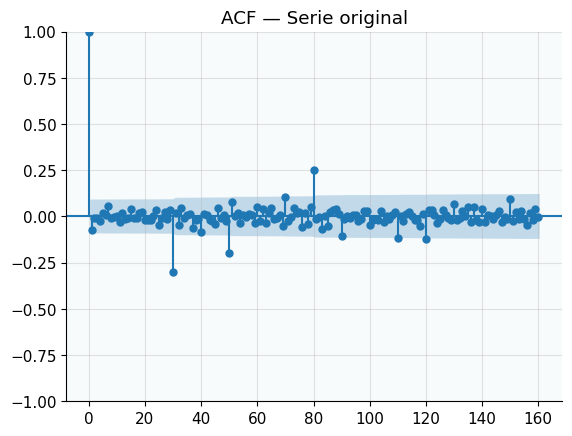

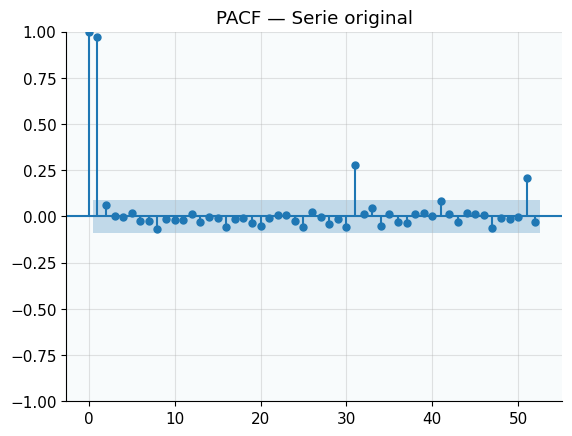

In [65]:
stl      = STL(train_s, period=52, robust=True).fit()
Fs       = max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
adf_orig = adfuller(train_s, autolag='AIC')[1] #--> menor a 0.05 soy estacional
adf_diff = adfuller(train_s.diff().dropna(), autolag='AIC')[1]

print(adf_orig   , adf_diff, Fs)

plot_acf(train_s.diff().dropna(), lags=160); plt.title('ACF — Serie original')
plt.show()
plot_pacf(train_s, lags=52); plt.title('PACF — Serie original')
plt.show()



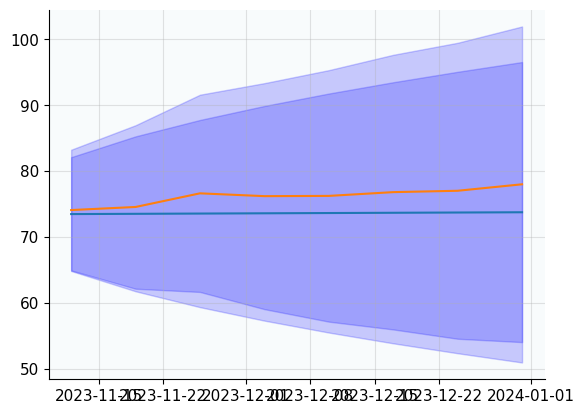

In [66]:
#Modelo ARIMA
d = 1
q = 1
p = 0

model_arima = pm.ARIMA(order=(p,d,q)).fit(train_s)

fc_arima, confint_arima = model_arima.predict(n_periods=HORIZON, return_conf_int=True)
df_arima = pd.DataFrame({'pred': fc_arima, 'lower': confint_arima[:, 0], 'upper': confint_arima[:, 1]}, index=test_s.index)
df_arima.head()

plt.plot(df_arima.index, df_arima['pred'])
plt.fill_between(df_arima.index, df_arima['lower'], df_arima['upper'], color='blue', alpha=0.2)

#Modelo SARIMA
model_sarima = pm.ARIMA( order=(p,d,q), seasonal_order=(p,d,q,52)).fit(train_s)

fc_sarima, confint_sarima = model_sarima.predict(n_periods=HORIZON, return_conf_int=True)
df_sarima = pd.DataFrame({'pred': fc_sarima, 'lower': confint_sarima[:, 0], 'upper': confint_sarima[:, 1]}, index=test_s.index)
df_sarima.head()

plt.plot(df_sarima.index, df_sarima['pred'])
plt.fill_between(df_sarima.index, df_sarima['lower'], df_sarima['upper'], color='blue', alpha=0.2)

## 3. Modelos con walk-forward validation

Cada modelo predice **1 semana adelante**, reentrena, avanza — nunca extrapola lejos.  
Esto elimina el forecast plano que vimos con horizonte 52.

In [70]:
HORIZON = 52
def walk_forward(serie_full, exog_full, horizon, seasonal=False, use_exog=False):
    """Walk-forward: entrena hasta t-1, predice t, avanza."""
    preds, lower, upper = [], [], []
    n = len(serie_full)

    for i in range(horizon):
        cutoff   = n - horizon + i
        y_train  = serie_full.iloc[:cutoff]
        x_train  = exog_full.iloc[:cutoff].values.reshape(-1,1) if use_exog else None
        x_pred   = exog_full.iloc[[cutoff]].values.reshape(-1,1) if use_exog else None

        model = pm.auto_arima(
            y_train,
            X=x_train,
            d=1,
            seasonal=seasonal, m=52 if seasonal else 1,
            max_P=1, max_Q=1,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )
        fc, ci = model.predict(n_periods=1, X=x_pred, return_conf_int=True)
        preds.append(fc[0])
        lower.append(ci[0][0])
        upper.append(ci[0][1])

    idx = serie_full.index[-horizon:]
    return (pd.Series(preds, index=idx),
            pd.Series(lower, index=idx),
            pd.Series(upper, index=idx))


serie_full = serie.dropna()
exog_full  = exog.reindex(serie_full.index).fillna(0)

print('Entrenando ARIMA  (walk-forward)...')
fc_arima,  lo_arima,  hi_arima  = walk_forward(serie_full, exog_full, HORIZON, seasonal=False, use_exog=False)

print('Entrenando SARIMA (walk-forward)...')
fc_sarima, lo_sarima, hi_sarima = walk_forward(serie_full, exog_full, HORIZON, seasonal=True,  use_exog=False)

test_wf = serie_full.iloc[-HORIZON:]
print('\nListo.')

Entrenando ARIMA  (walk-forward)...
Entrenando SARIMA (walk-forward)...

Listo.


## 4. Comparación de forecasts

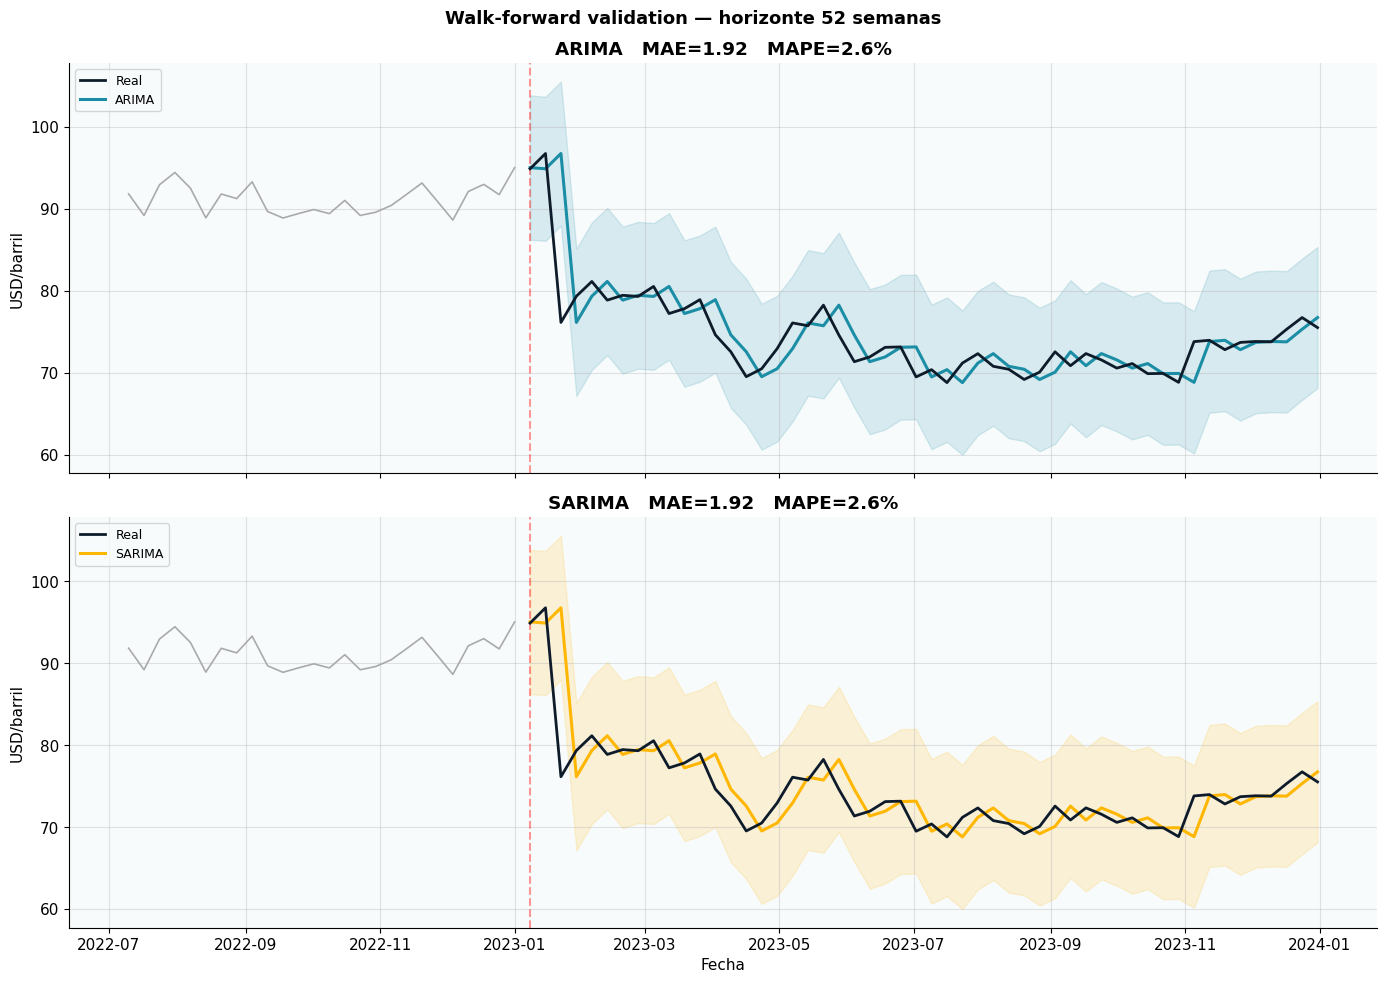

In [71]:

context = serie_full.iloc[-(HORIZON + 26):-HORIZON]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

models = [
    ('ARIMA',   fc_arima,  lo_arima,  hi_arima,  C['arima']),
    ('SARIMA',  fc_sarima, lo_sarima, hi_sarima, C['sarima'])
]

for ax, (name, fc, lo, hi, color) in zip(axes, models):
    ax.plot(context.index, context, color='#AAAAAA', lw=1.2)
    ax.axvline(test_wf.index[0], color='red', linestyle='--', alpha=0.4)
    ax.plot(test_wf.index, test_wf, color=C['real'], lw=2,   label='Real',  zorder=5)
    ax.plot(fc.index,      fc,      color=color,     lw=2.2, label=name,    zorder=4)
    ax.fill_between(fc.index, lo, hi, alpha=0.15, color=color)

    mae  = mean_absolute_error(test_wf, fc)
    mape = np.mean(np.abs((test_wf.values - fc.values) / test_wf.values)) * 100
    ax.set_title(f'{name}   MAE={mae:.2f}   MAPE={mape:.1f}%', fontweight='bold')
    ax.set_ylabel('USD/barril')
    ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xlabel('Fecha')
plt.suptitle(f'Walk-forward validation — horizonte {HORIZON} semanas', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()